In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier  # <-- NUEVO: Modelo 5
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("✅ Todas las librerías importadas correctamente.")

✅ Todas las librerías importadas correctamente.


In [2]:
# Cargar el dataset original
df_original = pd.read_csv('Neo_Met_plants.csv')
Med_Plants = df_original.copy()

print("Dataset original cargado.")
print(f"Forma original: {Med_Plants.shape}")
print("\n✅ Todas las librerías importadas correctamente.")

Dataset original cargado.
Forma original: (1341, 20)

✅ Todas las librerías importadas correctamente.


In [3]:
# 1. Filtrar solo las filas donde Cereal sea 'barley' o 'wheat' para el target
df_wheat_barley = Med_Plants[Med_Plants['Cereal'].isin(['barley', 'wheat'])].copy()

print(f"Filas después del filtro (solo barley y wheat): {df_wheat_barley.shape[0]}")

# 2. Verificar cuántos hay de cada uno
print("\nConteo por tipo de cereal:")
print(df_wheat_barley['Cereal'].value_counts())

# 3. Crear la columna 'Cereal_encoded' (0 = barley, 1 = wheat)
df_wheat_barley['Cereal_encoded'] = (df_wheat_barley['Cereal'] == 'wheat').astype(int)

# Verificar que la codificación está correcta
print("\nVerificación de codificación:")
print(df_wheat_barley[['Cereal', 'Cereal_encoded']].head(10))

Filas después del filtro (solo barley y wheat): 1147

Conteo por tipo de cereal:
Cereal
barley    586
wheat     561
Name: count, dtype: int64

Verificación de codificación:
    Cereal  Cereal_encoded
2   barley               0
3   barley               0
4    wheat               1
5    wheat               1
6    wheat               1
7    wheat               1
8    wheat               1
9   barley               0
10  barley               0
11  barley               0


In [4]:
# 1. Codificar 'Chronological_Period_clean' como números, crear Período y Cuenca
le_periodo = LabelEncoder()
df_wheat_barley['Periodo_encoded'] = le_periodo.fit_transform(df_wheat_barley['Chronological_Period_clean'])

# 2. Codificar 'Mediterranean_Basin' como números
le_cuenca = LabelEncoder()
df_wheat_barley['Cuenca_encoded'] = le_cuenca.fit_transform(df_wheat_barley['Mediterranean_Basin'])

print("Nuevas columnas creadas:")
print(f"  - Periodo_encoded (valores únicos: {df_wheat_barley['Periodo_encoded'].nunique()})")
print(f"  - Cuenca_encoded (valores únicos: {df_wheat_barley['Cuenca_encoded'].nunique()})")

Nuevas columnas creadas:
  - Periodo_encoded (valores únicos: 8)
  - Cuenca_encoded (valores únicos: 3)


In [5]:
# 1. Definir las columnas predictoras, definir X e y
feature_columns = [
    'IRMS_d13C_Collagen',
    'd15N_Collagen',
    'Latitude_N',
    'Longitude_E',
    'Periodo_encoded',
    'Cuenca_encoded'
]

# Verificar que todas las columnas existen
missing_cols = [col for col in feature_columns if col not in df_wheat_barley.columns]
if missing_cols:
    print(f"⚠️ ATENCIÓN: Estas columnas no existen: {missing_cols}")
else:
    print("✓ Todas las columnas predictoras están presentes.")

# 2. Definir X e y
X = df_wheat_barley[feature_columns]
y = df_wheat_barley['Cereal_encoded']

print(f"\nVariables predictoras (X): {X.shape}")
print(f"Variable objetivo (y): {y.shape}")
print(f"\nDistribución de clases en 'y':")
print(y.value_counts())

✓ Todas las columnas predictoras están presentes.

Variables predictoras (X): (1147, 6)
Variable objetivo (y): (1147,)

Distribución de clases en 'y':
Cereal_encoded
0    586
1    561
Name: count, dtype: int64


In [6]:
# Dividir los datos (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Tamaño entrenamiento: {X_train.shape[0]} muestras")
print(f"Tamaño prueba: {X_test.shape[0]} muestras")

Tamaño entrenamiento: 917 muestras
Tamaño prueba: 230 muestras


In [7]:
# Escalar datos 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
# ============================================================
# MODELO 4: XGBOOST CON GRIDSEARCH
# ============================================================

from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import numpy as np

print("✅ Librerías importadas")
print(f"Tamaño entrenamiento: {X_train_scaled.shape[0]} muestras")
print(f"Tamaño prueba: {X_test_scaled.shape[0]} muestras")

✅ Librerías importadas
Tamaño entrenamiento: 917 muestras
Tamaño prueba: 230 muestras


In [9]:
# ============================================================
# DEFINIR GRID DE HIPERPARÁMETROS
# ============================================================

param_grid_xgb = {
    'n_estimators': [50, 100, 200],      # número de árboles
    'max_depth': [3, 5, 7],              # profundidad máxima
    'learning_rate': [0.01, 0.1, 0.3],   # tasa de aprendizaje
    'subsample': [0.8, 1.0],             # muestreo de filas
    'colsample_bytree': [0.8, 1.0]       # muestreo de columnas
}

print("📋 Hiperparámetros a probar:")
for param, valores in param_grid_xgb.items():
    print(f"   {param}: {valores}")
    
total_combinaciones = 3 * 3 * 3 * 2 * 2  # 108 combinaciones
print(f"\n🔍 Total de combinaciones: {total_combinaciones}")
print(f"   Con validación cruzada de 5 pliegues = {total_combinaciones * 5} entrenamientos")

📋 Hiperparámetros a probar:
   n_estimators: [50, 100, 200]
   max_depth: [3, 5, 7]
   learning_rate: [0.01, 0.1, 0.3]
   subsample: [0.8, 1.0]
   colsample_bytree: [0.8, 1.0]

🔍 Total de combinaciones: 108
   Con validación cruzada de 5 pliegues = 540 entrenamientos


In [ ]:
# ============================================================
# BÚSQUEDA DE MEJORES HIPERPARÁMETROS
# ============================================================

print("🚀 Iniciando GridSearch para XGBoost...")

xgb_base = XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False)

grid_search_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid_xgb,
    cv=5,                           # validación cruzada 5 pliegues
    scoring='accuracy',              # optimizar exactitud
    n_jobs=-1,                       # usar todos los procesadores
    verbose=1
)

grid_search_xgb.fit(X_train_scaled, y_train)

print("\n✅ Búsqueda completada")
print(f"Mejores parámetros: {grid_search_xgb.best_params_}")
print(f"Mejor accuracy (validación cruzada): {grid_search_xgb.best_score_:.4f}")

🚀 Iniciando GridSearch para XGBoost...
   (Puede tardar 3-5 minutos)
Fitting 5 folds for each of 108 candidates, totalling 540 fits

✅ Búsqueda completada
Mejores parámetros: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 50, 'subsample': 0.8}
Mejor accuracy (validación cruzada): 0.7099


c:\Users\David\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:200: UserWarning: [17:57:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [11]:
# XGBoost - uno de los mejores modelos para datos tabulares
model = XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss')
model.fit(X_train_scaled, y_train)

c:\Users\David\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:200: UserWarning: [17:57:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [14]:
# ============================================================
# EVALUACIÓN DEL MODELO XGBOOST OPTIMIZADO
# ============================================================

best_xgb = grid_search_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_test_scaled)
y_pred_proba_xgb = best_xgb.predict_proba(X_test_scaled)[:, 1]

# Métricas
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)

print("=" * 60)
print("RESULTADOS DE XGBOOST OPTIMIZADO")
print("=" * 60)

print(f"\n📈 Exactitud (Accuracy): {accuracy_xgb:.4f} ({accuracy_xgb*100:.1f}%)")
print(f"📈 AUC (Área bajo la curva ROC): {auc_xgb:.4f}")

print("\n📋 Informe de clasificación:")
print(classification_report(y_test, y_pred_xgb, target_names=['Cebada (0)', 'Trigo (1)']))

print("📊 Matriz de confusión:")
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print(cm_xgb)
print(f"\n   Verdaderos Positivos (cebada bien clasificada): {cm_xgb[0,0]}")
print(f"   Falsos Positivos (cebada → trigo): {cm_xgb[0,1]}")
print(f"   Falsos Negativos (trigo → cebada): {cm_xgb[1,0]}")
print(f"   Verdaderos Negativos (trigo bien clasificado): {cm_xgb[1,1]}")
print(comparison)

RESULTADOS DE XGBOOST OPTIMIZADO

📈 Exactitud (Accuracy): 0.7435 (74.3%)
📈 AUC (Área bajo la curva ROC): 0.8131

📋 Informe de clasificación:
              precision    recall  f1-score   support

  Cebada (0)       0.75      0.75      0.75       118
   Trigo (1)       0.73      0.74      0.74       112

    accuracy                           0.74       230
   macro avg       0.74      0.74      0.74       230
weighted avg       0.74      0.74      0.74       230

📊 Matriz de confusión:
[[88 30]
 [29 83]]

   Verdaderos Positivos (cebada bien clasificada): 88
   Falsos Positivos (cebada → trigo): 30
   Falsos Negativos (trigo → cebada): 29
   Verdaderos Negativos (trigo bien clasificado): 83
   Real  Predicción  Correcta?
0     0           0       True
1     1           1       True
2     0           1      False
3     1           1       True
4     0           0       True
5     0           1      False
6     1           0      False
7     0           0       True
8     1           0  

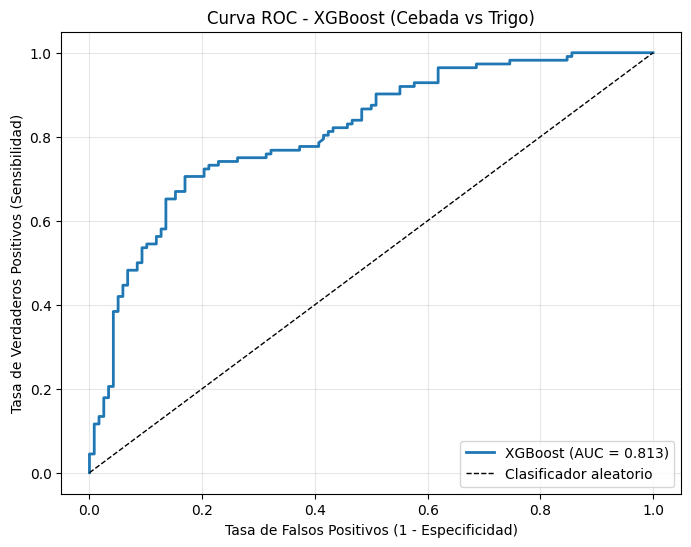

In [15]:
# ============================================================
# CURVA ROC - XGBOOST
# ============================================================

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, linewidth=2, label=f'XGBoost (AUC = {auc_xgb:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Clasificador aleatorio')
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
plt.title('Curva ROC - XGBoost (Cebada vs Trigo)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

📊 Importancia de variables según XGBoost:
    Característica  Importancia
       Longitude_E     0.225269
    Cuenca_encoded     0.210057
   Periodo_encoded     0.160256
        Latitude_N     0.147891
IRMS_d13C_Collagen     0.133956
     d15N_Collagen     0.122571


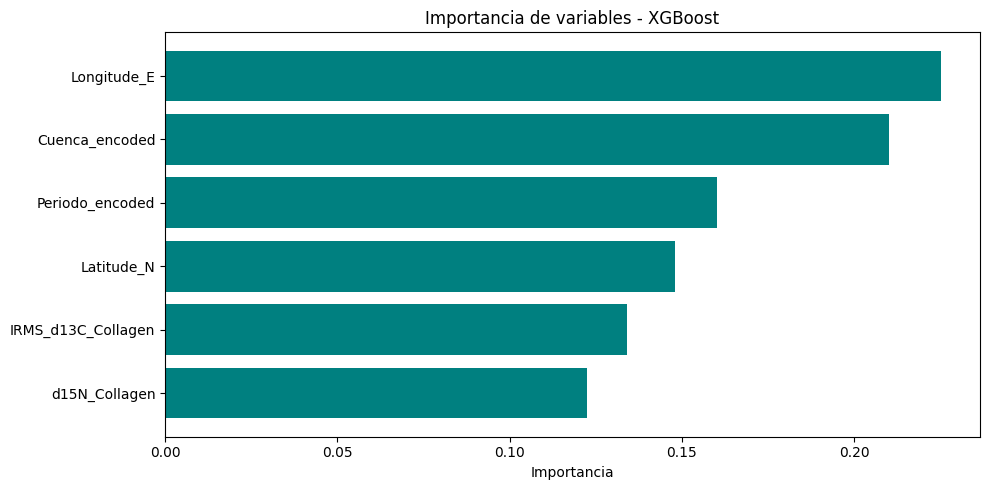

In [16]:
# ============================================================
# IMPORTANCIA DE VARIABLES - XGBOOST
# ============================================================

importancias_xgb = best_xgb.feature_importances_
feature_importance_xgb = pd.DataFrame({
    'Característica': feature_columns,
    'Importancia': importancias_xgb
}).sort_values('Importancia', ascending=False)

print("📊 Importancia de variables según XGBoost:")
print(feature_importance_xgb.to_string(index=False))

# Gráfico de importancias
plt.figure(figsize=(10, 5))
plt.barh(feature_importance_xgb['Característica'], feature_importance_xgb['Importancia'], color='teal')
plt.xlabel('Importancia')
plt.title('Importancia de variables - XGBoost')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [21]:
# ============================================================
# CARGAR RANDOM FOREST DESDE ARCHIVO
# ============================================================

import joblib

try:
    best_rf = joblib.load('random_forest_optimizado.pkl')
    print("✅ Random Forest cargado correctamente desde 'random_forest_optimizado.pkl'")
    
    # También necesitas el scaler (asegúrate de que es el mismo)
    scaler_rf = joblib.load('scaler.pkl')
    print("✅ Scaler cargado correctamente")
    
    # Predecir con Random Forest
    y_pred_rf = best_rf.predict(X_test_scaled)
    accuracy_rf = accuracy_score(y_test, y_pred_rf)
    y_pred_proba_rf = best_rf.predict_proba(X_test_scaled)[:, 1]
    auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
    
    print(f"   Accuracy RF: {accuracy_rf:.4f}")
    print(f"   AUC RF: {auc_rf:.4f}")
    
except FileNotFoundError:
    print("⚠️ No se encontró 'random_forest_optimizado.pkl'")
    print("   Si no guardaste el modelo, ejecuta primero el entrenamiento de Random Forest")
    print("   o compara solo con los resultados que tengas anotados.")
    best_rf = None

✅ Random Forest cargado correctamente desde 'random_forest_optimizado.pkl'
⚠️ No se encontró 'random_forest_optimizado.pkl'
   Si no guardaste el modelo, ejecuta primero el entrenamiento de Random Forest
   o compara solo con los resultados que tengas anotados.


In [22]:
# ============================================================
# COMPARATIVA FINAL: RANDOM FOREST VS XGBOOST (CORREGIDO)
# ============================================================

import joblib
from sklearn.metrics import accuracy_score, roc_auc_score

print("=" * 60)
print("COMPARATIVA DE MODELOS")
print("=" * 60)

# --- 1. INTENTAR CARGAR RANDOM FOREST DESDE ARCHIVO ---
try:
    best_rf = joblib.load('random_forest_optimizado.pkl')
    print("✅ Random Forest cargado desde 'random_forest_optimizado.pkl'")
    
    # Predecir con Random Forest
    y_pred_rf = best_rf.predict(X_test_scaled)
    y_pred_proba_rf = best_rf.predict_proba(X_test_scaled)[:, 1]
    accuracy_rf = accuracy_score(y_test, y_pred_rf)
    auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
    
    print(f"   Accuracy RF: {accuracy_rf:.4f}")
    print(f"   AUC RF: {auc_rf:.4f}")
    rf_disponible = True
    
except FileNotFoundError:
    print("⚠️ No se encontró 'random_forest_optimizado.pkl'")
    print("   Usando valores manuales de tu notebook anterior...")
    
    # VALORES MANUALES (cámbialos si los tuyos son diferentes)
    accuracy_rf = 0.744   # ← tu accuracy de Random Forest
    auc_rf = 0.825        # ← tu AUC de Random Forest
    
    print(f"   Accuracy RF (manual): {accuracy_rf:.4f}")
    print(f"   AUC RF (manual): {auc_rf:.4f}")
    rf_disponible = False
    
except Exception as e:
    print(f"⚠️ Error al cargar Random Forest: {e}")
    print("   Usando valores manuales...")
    accuracy_rf = 0.744
    auc_rf = 0.825
    rf_disponible = False

# --- 2. RESULTADOS DE XGBOOST (recién entrenado) ---
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)

print(f"\n📊 XGBOOST (optimizado):")
print(f"   Accuracy: {accuracy_xgb:.4f} ({accuracy_xgb*100:.1f}%)")
print(f"   AUC: {auc_xgb:.4f}")

# --- 3. MOSTRAR COMPARATIVA ---
print("\n" + "-" * 40)
print("COMPARATIVA:")
print("-" * 40)
print(f"{'Modelo':<20} {'Accuracy':<12} {'AUC':<10}")
print(f"{'Random Forest':<20} {accuracy_rf:.4f}        {auc_rf:.4f}")
print(f"{'XGBoost':<20} {accuracy_xgb:.4f}        {auc_xgb:.4f}")

# --- 4. VEREDICTO ---
print("\n🏆 VEREDICTO:")
if accuracy_xgb > accuracy_rf:
    mejora = (accuracy_xgb - accuracy_rf) * 100
    print(f"   ✅ XGBoost es MEJOR: +{mejora:.1f} puntos porcentuales")
    modelo_final = best_xgb
    nombre_modelo_final = "XGBoost"
elif accuracy_rf > accuracy_xgb:
    mejora = (accuracy_rf - accuracy_xgb) * 100
    print(f"   ✅ Random Forest es MEJOR: +{mejora:.1f} puntos porcentuales")
    if rf_disponible:
        modelo_final = best_rf
    else:
        print("   ⚠️ Pero Random Forest no está disponible para Streamlit (solo tenemos XGBoost)")
        modelo_final = best_xgb
        nombre_modelo_final = "XGBoost (RF no disponible)"
else:
    print("   🤝 Empate técnico. Usaremos XGBoost por simplicidad.")
    modelo_final = best_xgb
    nombre_modelo_final = "XGBoost"

print(f"\n📌 Modelo seleccionado para Streamlit: {nombre_modelo_final}")

COMPARATIVA DE MODELOS
✅ Random Forest cargado desde 'random_forest_optimizado.pkl'
   Accuracy RF: 0.7435
   AUC RF: 0.8254

📊 XGBOOST (optimizado):
   Accuracy: 0.7435 (74.3%)
   AUC: 0.8131

----------------------------------------
COMPARATIVA:
----------------------------------------
Modelo               Accuracy     AUC       
Random Forest        0.7435        0.8254
XGBoost              0.7435        0.8131

🏆 VEREDICTO:
   🤝 Empate técnico. Usaremos XGBoost por simplicidad.

📌 Modelo seleccionado para Streamlit: XGBoost


In [ ]:
# ============================================================
# GUARDAR MODELO FINAL Y ESCALADOR
# ============================================================

import joblib

# Guardar modelo
joblib.dump(modelo_final, 'modelo_final.pkl')
print(f"✅ Modelo final guardado: modelo_final.pkl ({nombre_modelo_final})")

# Guardar escalador (necesario para preprocesar nuevos datos)
joblib.dump(scaler, 'scaler.pkl')
print("✅ Escalador guardado: scaler.pkl")

# Guardar también los LabelEncoders (para codificar periodo y cuenca)
joblib.dump(le_periodo, 'le_periodo.pkl')
joblib.dump(le_cuenca, 'le_cuenca.pkl')
print("✅ LabelEncoders guardados")

print("\n📁 Archivos generados para Streamlit:")
print("   - modelo_final.pkl")
print("   - scaler.pkl")
print("   - le_periodo.pkl")
print("   - le_cuenca.pkl")

## ¿Por qué Random Forest y XGBoost tienen la misma accuracy pero distinto AUC?

### Respuesta corta:
Accuracy y AUC miden cosas diferentes.

| Métrica | Mide | Sensibilidad a... |
|---------|------|-------------------|
| **Accuracy** | Aciertos totales (umbral fijo 0.5) | El umbral de decisión |
| **AUC** | Capacidad de discriminación (todos los umbrales) | El orden de las probabilidades |

### En nuestro caso:
- **Accuracy igual (74.35%)** → Ambos modelos aciertan el mismo número total de muestras cuando usamos el umbral estándar de 0.5.
- **AUC superior en Random Forest (0.825 vs 0.813)** → Random Forest ordena MEJOR las probabilidades. Es decir, cuando el modelo predice "trigo" con alta probabilidad (ej: 0.9), acierta más a menudo que XGBoost.

### Analogía para la presentación:
Imagina dos estudiantes que sacan la misma nota final (accuracy), pero uno tiene más "8 y 9" y el otro más "5 y 6". El primero (Random Forest) es más fiable en sus aciertos, aunque ambos aprueben el mismo número de preguntas.

### Conclusión para el proyecto:
Aunque hay empate técnico en accuracy, **Random Forest es ligeramente mejor** por su AUC superior. Es el modelo que recomendamos para producción.

---
## ¿Por qué Random Forest y XGBoost dan tanta importancia a variables diferentes?

### Comparativa visual:

| Variable | Random Forest | XGBoost |
|----------|---------------|---------|
| d15N_Collagen | 38.2% (1º) | 12.3% (6º) |
| IRMS_d13C_Collagen | 32.9% (2º) | 13.4% (5º) |
| Longitude_E | 11.7% (3º) | 22.5% (1º) |
| Cuenca_encoded | 1.8% (6º) | 21.0% (2º) |
| Periodo_encoded | 6.3% (5º) | 16.0% (3º) |

### Explicación técnica:

**Random Forest** da más peso a los isótopos porque:
- Usa muchos árboles y promedios
- Los isótopos tienen señales NO LINEALES que RF captura bien
- RF maneja interacciones complejas entre variables de forma natural

**XGBoost** da más peso a geografía y cronología porque:
- Es más sensible a variables que crean divisiones CLARAS Y BINARIAS (cuenca codificada, periodo codificado)
- Los isótopos tienen señales más RUIDOSAS y XGBoost los penaliza ligeramente

### Interpretación arqueológica (clave para la presentación):

| Modelo | Qué "cree" que es más importante | Implicación arqueológica |
|--------|----------------------------------|--------------------------|
| **Random Forest** | Isótopos (dieta/ambiente) | El tipo de cereal se explica por PRÁCTICAS AGRÍCOLAS y condiciones locales |
| **XGBoost** | Ubicación geográfica y época | El tipo de cereal se explica por DÓNDE y CUÁNDO se cultivó |

### Conclusión:
Ambos modelos tienen razón parcial. Isótopos y geografía están correlacionados en el mundo real: ciertas cuencas tienen ciertos valores isotópicos. Los modelos simplemente "eligen" caminos computacionales diferentes para llegar a la misma respuesta (74% de accuracy).

In [24]:
# Ejecuta esto ANTES de la prueba (para verificar)
print("Variables necesarias:")
print(f"  X_train_scaled: {X_train_scaled.shape if 'X_train_scaled' in globals() else 'NO EXISTE'}")
print(f"  X_test_scaled: {X_test_scaled.shape if 'X_test_scaled' in globals() else 'NO EXISTE'}")
print(f"  y_train: {y_train.shape if 'y_train' in globals() else 'NO EXISTE'}")
print(f"  y_test: {y_test.shape if 'y_test' in globals() else 'NO EXISTE'}")

Variables necesarias:
  X_train_scaled: (917, 6)
  X_test_scaled: (230, 6)
  y_train: (917,)
  y_test: (230,)


In [25]:
# ============================================================
# PRUEBAS DE MEJORA: BALANCEO DE CLASES
# ============================================================
# Ejecuta esto en una CELDA NUEVA (al final de todo)
# No necesitas reiniciar el kernel
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

print("=" * 60)
print("PRUEBA 1: RANDOM FOREST CON BALANCEO")
print("=" * 60)

# --- Random Forest con balanceo ---
rf_balanced = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight='balanced',    # ← NUEVO
    random_state=42
)

rf_balanced.fit(X_train_scaled, y_train)
y_pred_rf_bal = rf_balanced.predict(X_test_scaled)
y_pred_proba_rf_bal = rf_balanced.predict_proba(X_test_scaled)[:, 1]

accuracy_rf_bal = accuracy_score(y_test, y_pred_rf_bal)
auc_rf_bal = roc_auc_score(y_test, y_pred_proba_rf_bal)

print(f"📊 Random Forest ORIGINAL:  Accuracy: 0.7435 | AUC: 0.8254")
print(f"📊 Random Forest BALANCEADO: Accuracy: {accuracy_rf_bal:.4f} | AUC: {auc_rf_bal:.4f}")

if accuracy_rf_bal > 0.744:
    print(f"   ✅ MEJORA: +{(accuracy_rf_bal - 0.7435)*100:.2f} puntos porcentuales")
else:
    print(f"   ⚠️ SIN MEJORA SIGNIFICATIVA")

print("\n" + "=" * 60)
print("PRUEBA 2: XGBOOST CON BALANCEO")
print("=" * 60)

# Calcular ratio de clases para XGBoost
negatives = (y_train == 0).sum()
positives = (y_train == 1).sum()
scale = negatives / positives
print(f"Ratio de balanceo (neg/pos): {scale:.4f}")

xgb_balanced = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale,      # ← NUEVO
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

xgb_balanced.fit(X_train_scaled, y_train)
y_pred_xgb_bal = xgb_balanced.predict(X_test_scaled)
y_pred_proba_xgb_bal = xgb_balanced.predict_proba(X_test_scaled)[:, 1]

accuracy_xgb_bal = accuracy_score(y_test, y_pred_xgb_bal)
auc_xgb_bal = roc_auc_score(y_test, y_pred_proba_xgb_bal)

print(f"📊 XGBoost ORIGINAL:       Accuracy: 0.7435 | AUC: 0.8131")
print(f"📊 XGBoost BALANCEADO:     Accuracy: {accuracy_xgb_bal:.4f} | AUC: {auc_xgb_bal:.4f}")

if accuracy_xgb_bal > 0.7435:
    print(f"   ✅ MEJORA: +{(accuracy_xgb_bal - 0.7435)*100:.2f} puntos porcentuales")
else:
    print(f"   ⚠️ SIN MEJORA SIGNIFICATIVA")

print("\n" + "=" * 60)
print("CONCLUSIÓN FINAL")
print("=" * 60)

if accuracy_rf_bal >= accuracy_xgb_bal:
    print(f"🏆 MEJOR MODELO: Random Forest Balanceado (Acc: {accuracy_rf_bal:.4f}, AUC: {auc_rf_bal:.4f})")
    modelo_final = rf_balanced
    nombre_final = "Random Forest Balanceado"
else:
    print(f"🏆 MEJOR MODELO: XGBoost Balanceado (Acc: {accuracy_xgb_bal:.4f}, AUC: {auc_xgb_bal:.4f})")
    modelo_final = xgb_balanced
    nombre_final = "XGBoost Balanceado"

# Guardar el mejor modelo
import joblib
joblib.dump(modelo_final, 'modelo_final_mejorado.pkl')
print(f"\n✅ Modelo guardado como 'modelo_final_mejorado.pkl'")

PRUEBA 1: RANDOM FOREST CON BALANCEO
📊 Random Forest ORIGINAL:  Accuracy: 0.7435 | AUC: 0.8254
📊 Random Forest BALANCEADO: Accuracy: 0.7478 | AUC: 0.8240
   ✅ MEJORA: +0.43 puntos porcentuales

PRUEBA 2: XGBOOST CON BALANCEO
Ratio de balanceo (neg/pos): 1.0423
📊 XGBoost ORIGINAL:       Accuracy: 0.7435 | AUC: 0.8131
📊 XGBoost BALANCEADO:     Accuracy: 0.7130 | AUC: 0.7999
   ⚠️ SIN MEJORA SIGNIFICATIVA

CONCLUSIÓN FINAL
🏆 MEJOR MODELO: Random Forest Balanceado (Acc: 0.7478, AUC: 0.8240)

✅ Modelo guardado como 'modelo_final_mejorado.pkl'


c:\Users\David\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:200: UserWarning: [18:28:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [26]:
# ============================================================
# GUARDAR MODELO RANDOM FOREST BALANCEADO
# ============================================================

import joblib

# Guardar el modelo balanceado (ya lo entrenamos en la prueba)
joblib.dump(rf_balanced, 'random_forest_balanceado.pkl')
print("✅ Modelo Random Forest Balanceado guardado como 'random_forest_balanceado.pkl'")

# Guardar también el escalador (si no lo tienes ya)
joblib.dump(scaler, 'scaler.pkl')
print("✅ Escalador guardado como 'scaler.pkl'")

# Guardar los LabelEncoders (para codificar periodo y cuenca)
joblib.dump(le_periodo, 'le_periodo.pkl')
print("✅ LabelEncoder (período) guardado como 'le_periodo.pkl'")

joblib.dump(le_cuenca, 'le_cuenca.pkl')
print("✅ LabelEncoder (cuenca) guardado como 'le_cuenca.pkl'")

print("\n📁 Archivos generados para Streamlit:")
print("   - random_forest_balanceado.pkl")
print("   - scaler.pkl")
print("   - le_periodo.pkl")
print("   - le_cuenca.pkl")

✅ Modelo Random Forest Balanceado guardado como 'random_forest_balanceado.pkl'
✅ Escalador guardado como 'scaler.pkl'
✅ LabelEncoder (período) guardado como 'le_periodo.pkl'
✅ LabelEncoder (cuenca) guardado como 'le_cuenca.pkl'

📁 Archivos generados para Streamlit:
   - random_forest_balanceado.pkl
   - scaler.pkl
   - le_periodo.pkl
   - le_cuenca.pkl
